# Claudette Dataset Overview

This notebook summarizes the key statistics of the Claudette dataset contained in this repository.

In [1]:
import sys, importlib.util
sys.path.insert(0, '/workspace/2')
spec = importlib.util.spec_from_file_location('dataset', '/workspace/2/utils/dataset.py')
dataset_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dataset_module)
ClaudetteDataset = dataset_module.ClaudetteDataset
INT_TO_CODE = dataset_module.INT_TO_CODE
CODE_TO_FULL = dataset_module.CODE_TO_FULL
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
%matplotlib inline

In [2]:
dataset = ClaudetteDataset()
train_df = dataset.get_dataset('train')
val_df = dataset.get_dataset('val')
test_df = dataset.get_dataset('test')
all_df = dataset.get_dataset('all')


In [3]:
def summarize(df):
    col = 'document' if 'document' in df.columns else 'file_name'
    return pd.Series({'clauses': len(df), 'documents': df[col].nunique()})
summary = pd.DataFrame({
    'train': summarize(train_df),
    'val': summarize(val_df),
    'test': summarize(test_df),
    'all': summarize(all_df)
})
summary

,train,val,test,all
clauses,8354,8279,3784,20417
documents,40,40,20,100


In [4]:
# Count occurrences of each label across the full dataset
label_series = pd.Series([lbl for indices in all_df['label_indices'] for lbl in indices])
label_counts = label_series.value_counts().sort_index()
label_df = pd.DataFrame({
    'label': label_counts.index.map(INT_TO_CODE).map(CODE_TO_FULL),
    'count': label_counts.values
})
label_df

,label,count
0,Fairness,18239
1,Arbitration,106
2,Unilateral change,344
3,Content removal,216
4,Jurisdiction,136
5,Choice of law,148
6,Limitation of liability,626
7,?,102
8,Unilateral termination,420
9,Contract by using,296


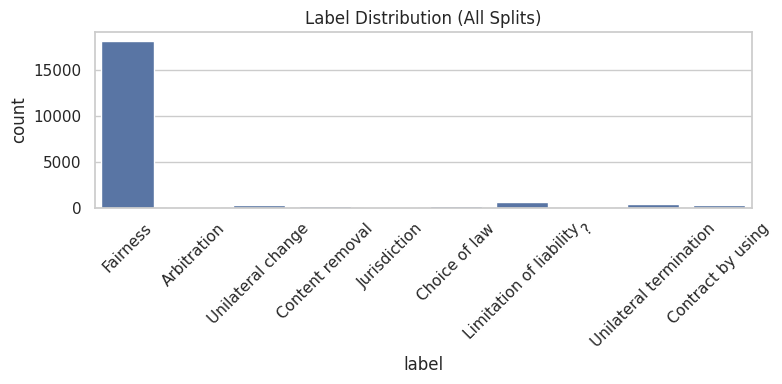

In [5]:
plt.figure(figsize=(8,4))
sns.barplot(x='label', y='count', data=label_df)
plt.title('Label Distribution (All Splits)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
all_df['char_len'] = all_df['text'].str.len()
all_df['word_len'] = all_df['text'].str.split().str.len()
all_df[['char_len','word_len']].describe()

,char_len,word_len
count,20417.000000,20417.000000
mean,179.817505,32.272714
std,139.720220,24.799487
min,13.000000,6.000000
25%,94.000000,17.000000
50%,145.000000,26.000000
75%,222.000000,39.000000
max,2023.000000,353.000000


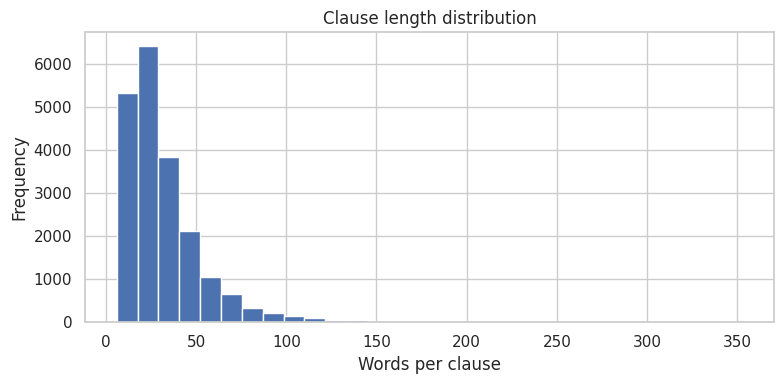

In [7]:
plt.figure(figsize=(8,4))
all_df['word_len'].hist(bins=30)
plt.xlabel('Words per clause')
plt.ylabel('Frequency')
plt.title('Clause length distribution')
plt.tight_layout()
plt.show()

In [8]:
# Show a few example unfair clauses
samples = dataset.sample_rows_from_all_unfair_labels('train', n=1)
for _, row in samples.iterrows():
    label_names = [INT_TO_CODE[l] for l in row['label_indices']]
    print('LABELS:', label_names)
    print(row['text'])
    print('-'*80)


LABELS: ['A']
your arbitration fees and your share of arbitrator compensation shall be governed by the aaa rules and , where appropriate , limited by the aaa consumer rules .
--------------------------------------------------------------------------------
LABELS: ['CH']
we retain the right , in our sole discretion , to implement new elements as part of and/or ancillary to the service , including changes that may affect the previous mode of operation of the service or evernote software .
--------------------------------------------------------------------------------
LABELS: ['CR']
we reserve the right to block or remove your content for any reason , including as is in our opinion appropriate , as required by applicable laws and regulations or in accordance with the copyright policy .
--------------------------------------------------------------------------------
LABELS: ['J']
you and headspace consent to the personal jurisdiction of both courts .
--------------------------------------